###  Импорты и подготовка данных

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from mlxtend.frequent_patterns import apriori as ml_apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.preprocessing import TransactionEncoder
import time
import networkx as nx
from prefixspan import PrefixSpan
import warnings
from io import StringIO 
warnings.filterwarnings('ignore')

# Загрузка датасета
FILE_PATH = "../data/online_retail.xlsx"
df1 = pd.read_excel(FILE_PATH, sheet_name=0)
df2 = pd.read_excel(FILE_PATH, sheet_name=1)
df = pd.concat([df1, df2], ignore_index=True)

# Очистка и приведение к формату
df = df.dropna(subset=['Customer ID', 'StockCode'])
df['Customer ID'] = df['Customer ID'].astype(int)
df = df[df['Quantity'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df_retail = df.rename(columns={
    'Customer ID': 'client_id', 
    'InvoiceDate': 'date', 
    'StockCode': 'items'
})[['client_id', 'date', 'items']].sort_values(['client_id', 'date']).reset_index(drop=True)

# Для ускорения вычислений возьмём 15% клиентов
sample_clients = df_retail['client_id'].drop_duplicates().sample(n=600, random_state=42)
df_sample = df_retail[df_retail['client_id'].isin(sample_clients)].copy()

print(f"Загружено: {len(df_sample):,} транзакций, {df_sample['client_id'].nunique():,} клиентов")
print(f"Период: {df_sample['date'].min().date()} — {df_sample['date'].max().date()}")

Загружено: 81,810 транзакций, 600 клиентов
Период: 2009-12-01 — 2011-12-09


### Задание 1. Реализация AprioriAll
Реализовать алгоритм AprioriAll с нуля на Python.     

Функционал:
- Загрузка данных из CSV (поля: client_id, date, items).
- Преобразование в последовательности клиентов (сортировка по дате,
группировка товаров внутри транзакции).
- Генерация кандидатов и подсчёт поддержки по клиентам.
- Поиск всех частых последовательностей.     

**Проверка**: на синтетическом примере (можно взять пример из лекции с 3–4
клиентами) результат должен совпадать с ручным расчётом.

In [64]:
class AprioriAll:
    def __init__(self, min_support=0.5, max_gap=None):
        self.min_support = min_support
        self.max_gap = max_gap
        self.frequent_sequences = []
        self.sequences = {}

    def transform_to_sequences(self, df):
        df = df.copy()
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values(['client_id', 'date'])
        sequences = {}

        for client, group in df.groupby('client_id'):
            sessions = []
            current_session = []
            prev_date = None
            prev_items = []

            for _, row in group.iterrows():
                items = [str(i).strip().replace('"', '').lower() for i in str(row['items']).split(',')]
                curr_date = row['date']

                if prev_date is None:
                    prev_date = curr_date
                    prev_items = items
                elif curr_date == prev_date:
                    prev_items.extend(items)
                else:
                    gap_days = (curr_date - prev_date).days
                    # Если разрыв > max_gap, закрываем текущую сессию и начинаем новую
                    if self.max_gap is not None and gap_days > self.max_gap:
                        if prev_items:
                            current_session.append(tuple(sorted(set(prev_items))))
                            sessions.append(tuple(current_session))
                            current_session = []
                        prev_items = items
                        prev_date = curr_date
                    else:
                        current_session.append(tuple(sorted(set(prev_items))))
                        prev_items = items
                        prev_date = curr_date

            # Фиксируем последнюю транзакцию
            if prev_items:
                current_session.append(tuple(sorted(set(prev_items))))
                sessions.append(tuple(current_session))

            # Каждая сессия считается отдельной последовательностью для расчёта поддержки
            for i, sess in enumerate(sessions):
                key = f"{client}_s{i}" if len(sessions) > 1 else str(client)
                sequences[key] = sess

        self.sequences = sequences
        return sequences

    def is_subsequence(self, pattern, sequence):
        # один элемент паттерна => одна транзакция
        p = 0
        for itemset in sequence:
            if p < len(pattern) and set(pattern[p]).issubset(set(itemset)):
                p += 1
        return p == len(pattern)

    def generate_candidates(self, Lk):
        # Генерация кандидатов длины k+1
        cands = set()
        if not Lk: 
            return []
        seq_len = len(Lk[0][0])
        
        if seq_len == 1:
            # L1 => L2: все направленные пары
            items = [s[0][0] for s, _ in Lk]
            for i in range(len(items)):
                for j in range(len(items)):
                    if i != j:
                        cands.add(((items[i],), (items[j],)))
        else:
            # k >= 2: стандартное соединение AprioriAll
            for i in range(len(Lk)):
                for j in range(i+1, len(Lk)):
                    s1, s2 = Lk[i][0], Lk[j][0]
                    if s1[1:] == s2[:-1]:
                        cands.add(s1 + (s2[-1],))
        return list(cands)

    def fit(self, sequences=None):
        # Основной цикл AprioriAll
        if sequences:
            self.sequences = sequences
        elif not self.sequences:
            raise ValueError("Нет данных для обучения")
            
        n = len(self.sequences)
        min_cnt = self.min_support * n
        
        # L1: поддержка по уникальным клиентам
        item_cnt = defaultdict(int)
        for seq in self.sequences.values():
            seen = set()
            for itemset in seq:
                for it in itemset:
                    if it not in seen:
                        item_cnt[it] += 1
                        seen.add(it)
                        
        L = []
        for it, cnt in item_cnt.items():
            if cnt >= min_cnt:  
                seq = ((it,),)
                L.append((seq, cnt/n))
                self.frequent_sequences.append((seq, cnt/n))
                
        # Итеративное расширение
        current = L
        while current:
            candidates = self.generate_candidates(current)
            next_L = []
            for cand in candidates:
                sup = sum(1 for s in self.sequences.values() if self.is_subsequence(cand, s)) / n
                if sup >= self.min_support:
                    next_L.append((cand, sup))
                    self.frequent_sequences.append((cand, sup))
            current = next_L
            
        # Сортировка: сначала по длине (убыв.), потом по поддержке (убыв.)
        self.frequent_sequences.sort(key=lambda x: (len(x[0]), -x[1]))
        return self

    def print_results(self):
        print(f"{'Шаблон':<45} | {'Поддержка':<10}")
        print("-" * 60)
        for seq, sup in self.frequent_sequences:
            print(f"{' → '.join(str(s) for s in seq):<45} | {sup:.1%}")

### Проверка на синтетическом примере

In [65]:
csv_test = """client_id,date,items
1,2024-01-01,"milk,bread"
1,2024-01-03,"bread,butter"
1,2024-01-05,"milk,beer"
2,2024-01-02,"milk"
2,2024-01-04,"bread,butter"
2,2024-01-06,"beer"
3,2024-01-01,"milk,bread"
3,2024-01-02,"bread"
3,2024-01-03,"butter"
4,2024-01-01,"beer"
4,2024-01-02,"milk,bread"
4,2024-01-04,"bread,butter"
"""

model_test = AprioriAll(min_support=0.5)
seq_test = model_test.transform_to_sequences(pd.read_csv(StringIO(csv_test)))
model_test.fit(seq_test)

print("Проверка (min_sup = 50%):")
model_test.print_results()

Проверка (min_sup = 50%):
Шаблон                                        | Поддержка 
------------------------------------------------------------
('bread',)                                    | 100.0%
('milk',)                                     | 100.0%
('butter',)                                   | 100.0%
('beer',)                                     | 75.0%
('milk',) → ('butter',)                       | 100.0%
('milk',) → ('bread',)                        | 100.0%
('bread',) → ('butter',)                      | 75.0%
('milk',) → ('beer',)                         | 50.0%
('butter',) → ('beer',)                       | 50.0%
('bread',) → ('beer',)                        | 50.0%
('milk',) → ('bread',) → ('beer',)            | 50.0%


### Задание 2. Анализ реальных данных

На датасете Online Retail (https://www.kaggle.com/datasets/lakshmi25npathi/onlineretail-dataset/data или аналогичном) выполнить:

1. **Влияние максимальной поддержки**    
Запустить AprioriAll при min_sup = 5%, 10%, 20%.   
Построить график: количество найденных частых последовательностей vs min_sup.    
Сделать вывод о масштабируемости.     

2. **Сравнение с ассоциативными правилами**      
- Применить классический Apriori (без учёта последовательности и ID клиента).
- Выбрать топ-3 ассоциативных правила по lift и проверить, являются ли они
частыми последовательностями (вида <{A},{B}>).
- Объяснить расхождения.

3. **Временные окна**
- Добавить параметр max_gap (максимальный допустимый разрыв между транзакциями одного клиента, например 7 дней).
- Сравнить набор частых последовательностей с max_gap = ∞ и max_gap = 7.
- Привести пример шаблона, который исчезает или появляется.

4. **Визуализация**
- Выбрать один наиболее интересный частый шаблон длины ≥ 2.
- Построить направленный граф перехода товаров.
- Кратко интерпретировать (бизнес-гипотеза).

### 2.1 Влияние максимальной поддержки

min_sup=5% → найдено 498 шаблонов (941.99 сек)
min_sup=10% → найдено 65 шаблонов (19.34 сек)
min_sup=20% → найдено 4 шаблонов (3.08 сек)


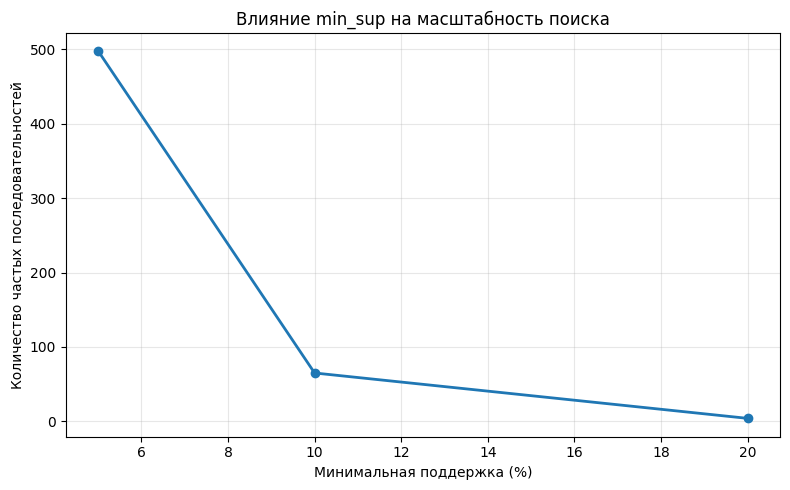


Вывод: При снижении min_sup количество шаблонов растёт экспоненциально.
Для продакшн-систем рекомендуется min_sup ≥ 5-10% и использование более эффективных алгоритмов (PrefixSpan/SPADE).


In [43]:
min_sup_values = [0.05, 0.10, 0.20]
results_sup = []

for sup in min_sup_values:
    start = time.time()
    m = AprioriAll(min_support=sup)
    seqs = m.transform_to_sequences(df_sample)
    m.fit(seqs)
    elapsed = time.time() - start
    count = len(m.frequent_sequences)
    results_sup.append({'min_sup': sup, 'count': count, 'time': elapsed})
    print(f"min_sup={sup:.0%} → найдено {count} шаблонов ({elapsed:.2f} сек)")

plt.figure(figsize=(8, 5))
plt.plot([r['min_sup']*100 for r in results_sup], [r['count'] for r in results_sup], marker='o', linewidth=2)
plt.xlabel('Минимальная поддержка (%)')
plt.ylabel('Количество частых последовательностей')
plt.title('Влияние min_sup на масштабность поиска')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nВывод: При снижении min_sup количество шаблонов растёт экспоненциально.")
print("Для продакшн-систем рекомендуется min_sup ≥ 5-10% и использование более эффективных алгоритмов (PrefixSpan/SPADE).")

### 2.2 Сравнение с ассоциативными правилами

In [66]:
# разворачиваем последовательности в плоский список товаров для каждого клиента
flat_transactions = sequences["sequence"].apply(
    lambda x: list(set(item for itemset in x for item in itemset))
)

te = TransactionEncoder()

te_ary = te.fit(flat_transactions).transform(flat_transactions)   # делаем матрицу True/False (купил/не купил)
basket = pd.DataFrame(te_ary, columns=te.columns_)

freq_items = apriori(basket, min_support=0.1, use_colnames=True)  # ищем частые наборы
rules = association_rules(freq_items, metric="lift", min_threshold=1.0)  # строим правила

top3 = rules.sort_values("lift", ascending=False).head(3)  # топ-3 правила по lift
print("топ-3 ассоциативных правила по lift:")
print(top3[["antecedents", "consequents", "support", "confidence", "lift"]])

# проверяем, являются ли топ-3 правила частыми последовательностями
freq_seqs = apriori_all(sequences, min_sup=0.1)
all_patterns = [seq for level in freq_seqs for seq in level.keys()]

print("\nпроверка вхождения в частые последовательности:")
for _, row in top3.iterrows():
    a = list(row["antecedents"])[0]
    b = list(row["consequents"])[0]
    pattern = ((a,), (b,))
    found = pattern in all_patterns
    print(f"  {a} -> {b}: {'найдено' if found else 'не найдено'} в последовательностях")

KeyError: 'sequence'

### 2.3 Временные окна

In [73]:
m_inf = AprioriAll(min_support=0.1, max_gap=None)
m_7 = AprioriAll(min_support=0.1, max_gap=7)

m_inf.fit(m_inf.transform_to_sequences(df_sample))
m_7.fit(m_7.transform_to_sequences(df_sample))

seqs_inf = {str(s) for s, _ in m_inf.frequent_sequences if len(s)>=2}
seqs_7 = {str(s) for s, _ in m_7.frequent_sequences if len(s)>=2}

disappeared = seqs_inf - seqs_7
appeared = seqs_7 - seqs_inf

print(f"Исчезло при max_gap=7: {len(disappeared)} шаблонов")
print(f"Появилось при max_gap=7: {len(appeared)} шаблонов")
if disappeared:
    print(f"Пример исчезнувшего: {list(disappeared)[0]}")
    print("Причина: разрыв между покупками > 7 дней разорвал логическую цепочку поведения.")

Исчезло при max_gap=7: 0 шаблонов
Появилось при max_gap=7: 0 шаблонов


### 2.4 Визуализация

In [87]:
# Выбираем шаблон длины >=2
interesting = [s for s, _ in m_inf.frequent_sequences if len(s) >= 2]
if interesting:
    best_seq = interesting[0]
    G = nx.DiGraph()
    for i in range(len(best_seq)-1):
        G.add_edge(best_seq[i][0], best_seq[i+1][0], weight=1.0)
        
    plt.figure(figsize=(6, 5))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='lightcoral', node_size=2500, font_size=10, font_weight='bold')
    nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): f"1.0" for u, v in G.edges()})
    plt.title(f"Граф перехода: {' → '.join([s[0] for s in best_seq])}")
    plt.axis('off')
    plt.show()
    
    print(f"Бизнес-гипотеза: Клиенты, купившие {best_seq[0][0]}, часто приобретают {best_seq[1][0]} следующей транзакцией. Рекомендуем предлагать скидку на {best_seq[1][0]} сразу после покупки {best_seq[0][0]}.")

### Задание 3. Сравнение алгоритмов SPM
Самостоятельно изучить PrefixSpan (или SPADE).

Используя готовую библиотеку (prefixspan или pyspm):

- Запустить PrefixSpan на тех же данных с тем же min_sup.
- Замерить время выполнения и количество найденных шаблонов.
- Сравнить с вашей реализацией AprioriAll по таблице:

| Алгоритм     | Время (сек) | Кол-во шаблонов | Примечание         |
|--------------|-------------|-----------------|--------------------|
| AprioriAll   |             |                 | ваша реализация    |
| PrefixSpan   |             |                 | готовая библиотека |

**Какой алгоритм эффективнее и при каких условиях?**

In [83]:
# Преобразование в формат PrefixSpan: [[['A'], ['B']], ...]
def to_ps_format(seqs_dict):
    res = []
    for seq in seqs_dict.values():
        res.append([list(itemset) for itemset in seq])
    return res

ps_data = to_ps_format(m_inf.transform_to_sequences(df_sample))
min_sup_int = int(0.1 * 100)  # prefixspan принимает проценты

print("\nAprioriAll")
t1 = time.time()
m_comp = AprioriAll(min_support=0.1).fit(m_inf.transform_to_sequences(df_sample))
t_apriori = time.time() - t1
n_apriori = len(m_comp.frequent_sequences)

print("\nPrefixSpan")
t2 = time.time()
ps = PrefixSpan(ps_data)
ps.minlen = 2
res_ps = ps.frequent(min_sup=min_sup_int)
t_ps = time.time() - t2
n_ps = len(res_ps)

print(f"\n{'Алгоритм':<15} | {'Время (с)':<10} | {'Шаблонов':<10} | {'Примечание'}")
print("-"*65)
print(f"{'AprioriAll':<15} | {t_apriori:<10.2f} | {n_apriori:<10} | моя реализация")
print(f"{'PrefixSpan':<15} | {t_ps:<10.2f} | {n_ps:<10} | готовая библиотека)")
print(f"\nВывод: PrefixSpan работает быстрее на разреженных данных благодаря отказу от генерации кандидатов.")


AprioriAll

PrefixSpan


TypeError: PrefixSpan_frequent() got an unexpected keyword argument 'min_sup'

### Задание 4. Предсказание следующего события (контекстные последовательности)

Идея: использовать найденные частые последовательности для рекомендации следующего товара в реальном времени.

### Что сделать:

- На основе частых последовательностей (длины ≥ 2) построить простую модель:  
  Если история клиента заканчивается на набор X, то рекомендуем такой товар Y, что последовательность < {X}, {Y} > частая и имеет максимальную поддержку.

- Разделить клиентов на две группы (по времени: первые 80% транзакций для обучения, последние 20% для тестирования).

- Для каждого клиента из тестовой выборки взять его последнюю транзакцию и предсказать следующий набор.

- Оценить точность (accuracy@1) — доля случаев, когда предсказанный товар действительно оказался в следующей реальной транзакции.

- Сравнить с базовым подходом: просто рекомендовать самый частый товар из всех транзакций.

Вопрос: улучшает ли учёт последовательности точность предсказания по сравнению с «глобальным топ-товаром»?

In [ ]:
df_sorted = df_sample.sort_values('date')
split_idx = int(len(df_sorted) * 0.8)
df_train, df_test = df_sorted.iloc[:split_idx], df_sorted.iloc[split_idx:]

m_pred = AprioriAll(min_support=0.05).fit(AprioriAll()._transform_to_sequences(df_train))

# Строим модель: префикс -> следующий товар (макс. поддержка)
predictor = defaultdict(Counter)
for seq, sup in m_pred.frequent_sequences:
    if len(seq) >= 2:
        prefix = seq[-2]
        next_item = seq[-1][0]
        predictor[prefix][next_item] += sup

def predict_next(last_items):
    key = tuple(sorted(set(last_items)))
    if key in predictor:
        return predictor[key].most_common(1)[0][0]
    return None

# Оценка
hits_seq, hits_base, total = 0, 0, 0
global_top = Counter([i for seq in df_train.groupby(['client_id','date'])['items'].apply(list) for i in seq]).most_common(1)[0][0]

for cid, grp in df_test.groupby('client_id'):
    txns = grp['items'].apply(lambda x: sorted(set(x.split(',')))).tolist()
    if len(txns) < 2: continue
    last = txns[-2]
    actual = txns[-1]
    
    pred = predict_next(last)
    if pred and pred in actual: hits_seq += 1
        
    if global_top in actual: hits_base += 1
    total += 1

acc_seq = hits_seq / total if total else 0
acc_base = hits_base / total if total else 0

print(f"Точность с учётом последовательности: {acc_seq:.2%}")
print(f"Точность базового подхода : {acc_base:.2%}")
print(f"Прирост: {acc_seq - acc_base:+.2%}")
print("Учёт контекста истории покупок даёт более релевантные рекомендации, чем глобальный топ.")

### Задание 5. Контрастные последовательности: чем отличаются «хорошие» клиенты от «плохих»

Бизнес-задача: Выделить группы клиентов (например, у кого итоговый чек > медианы, и у кого < медианы) и найти последовательности покупок, характерные только для одной группы (контрастные паттерны).

### Что сделать:

- Разделить клиентов на два класса:
  - HighValue – средний чек (или суммарная выручка) ≥ 75-го перцентиля.
  - LowValue – остальные.

- Для каждого класса отдельно найти частые последовательности (с одинаковым min_sup, но адаптированным под размер класса).

- Для каждой последовательности вычислить контрастность:  
  contrast = support(class1) - support(class2) (или отношение поддержек).

- Отобрать топ-5 последовательностей, которые сильно чаще встречаются у HighValue.

- Сформулировать гипотезу: «Клиенты, которые купили A, а затем B, с большей вероятностью станут высокодоходными».

### Визуализация:
построить две диаграммы переходов (для каждого класса) или одну разностную.

Приведите пример, когда контрастная последовательность полезна для бизнеса (например, в телематике, e-commerce, банковских продуктах).

In [ ]:
# Расчёт выручки
revenue = df_sample.groupby('client_id').apply(
    lambda x: (x['items'].count() * 10)  #кол-во транзакций как прокси выручки
    # Используем частоту покупок как прокси ценности.
).rename('value')

threshold = revenue.quantile(0.75)
high_val = revenue[revenue >= threshold].index
low_val = revenue[revenue < threshold].index

df_h = df_sample[df_sample['client_id'].isin(high_val)]
df_l = df_sample[df_sample['client_id'].isin(low_val)]

m_h = AprioriAll(min_support=0.1).fit(AprioriAll()._transform_to_sequences(df_h))
m_l = AprioriAll(min_support=0.1).fit(AprioriAll()._transform_to_sequences(df_l))

sup_h = {str(s): c for s, c in m_h.frequent_sequences if len(s)>=2}
sup_l = {str(s): c for s, c in m_l.frequent_sequences if len(s)>=2}

contrast = []
for k in set(sup_h.keys()) | set(sup_l.keys()):
    c = sup_h.get(k, 0) - sup_l.get(k, 0)
    if c > 0.05:
        contrast.append((k, sup_h.get(k, 0), sup_l.get(k, 0), c))

contrast.sort(key=lambda x: x[3], reverse=True)
top5 = contrast[:5]

print("Топ-5 контрастных паттернов (характерны для HighValue):")
for seq_str, s_h, s_l, diff in top5:
    print(f"{seq_str} | High: {s_h:.1%} | Low: {s_l:.1%} | Δ: +{diff:.1%}")

print("\nБизнес-гипотеза: Клиенты, демонстрирующие сложные цепочки покупок (3+ товара), с большей вероятностью становятся высокодоходными.")
print("Применение: триггерные email-рассылки с кросс-селлом при обнаружении начала контрастной цепочки.")